In [241]:
!pip install -q pandas
!pip install -q numpy
!pip install -q torch
!pip install -q pandas-ta
!pip install -q yfinance
!pip install -q matplotlib
!pip install -q scipy
!pip install -q prophet
!pip install -q holidays
!pip install -q antropy
!pip install -q hurst
!pip install -q PyWavelets
!pip install -q librosa
!pip install -q TA-Lib


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip instal

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
import pandas_ta as ta
import holidays
from statsmodels.tsa.stattools import acf, pacf
from scipy.signal import argrelextrema
import antropy as ant
from hurst import compute_Hc
import numpy as np
import scipy
from scipy.fft import fft
import pywt

from scipy.fft import fft
from scipy.signal import periodogram

import scipy.stats
import pywt
from scipy.stats import entropy as shannon_entropy

In [243]:
dat = yf.Ticker("BZ=F")
df = dat.history(period='5y')
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-06-07 00:00:00-04:00,71.699997,72.260002,71.099998,71.489998,21019,0.0,0.0
2021-06-08 00:00:00-04:00,71.389999,72.410004,70.720001,72.220001,29742,0.0,0.0
2021-06-09 00:00:00-04:00,72.139999,72.879997,71.820000,72.220001,31013,0.0,0.0
2021-06-10 00:00:00-04:00,72.089996,72.919998,70.949997,72.519997,37080,0.0,0.0
2021-06-11 00:00:00-04:00,72.389999,73.080002,71.879997,72.690002,36538,0.0,0.0


In [244]:
df.describe() 

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000,1259.0,1259.0
mean,82.089039,83.478348,80.672756,82.109587,34202.692613,0.0,0.0
std,13.400406,14.034665,12.791337,13.427276,20191.063264,0.0,0.0
min,58.939999,60.410000,58.389999,58.919998,0.000000,0.0,0.0
25%,72.935001,73.829998,71.869999,72.930000,23428.000000,0.0,0.0
50%,80.019997,81.480003,78.830002,79.940002,31013.000000,0.0,0.0
75%,88.110001,89.685001,86.704998,88.170002,40577.500000,0.0,0.0
max,129.570007,137.000000,122.500000,127.980003,235965.000000,0.0,0.0


In [245]:
df = df.drop(['Dividends', 'Stock Splits'], axis=1)

df["body"] = df["Close"] - df["Open"]
df["range"] = df["High"] - df["Low"]
df["upper_wick"] = df["High"] - np.maximum(df["Open"], df["Close"])
df["lower_wick"] = np.minimum(df["Open"], df["Close"]) - df["Low"]
df["body_pct"] = df["body"] / df["Open"]
df["range_pct"] = df["range"] / df["Close"]
df["close_pos"] = (df["Close"] - df["Low"]) / df["range"]
df.head()

,Open,High,Low,Close,Volume,body,range,upper_wick,lower_wick,body_pct,range_pct,close_pos
Date,,,,,,,,,,,,
2021-06-07 00:00:00-04:00,71.699997,72.260002,71.099998,71.489998,21019,-0.209999,1.160004,0.560005,0.389999,-0.002929,0.016226,0.336205
2021-06-08 00:00:00-04:00,71.389999,72.410004,70.720001,72.220001,29742,0.830002,1.690002,0.190002,0.669998,0.011626,0.023401,0.887573
2021-06-09 00:00:00-04:00,72.139999,72.879997,71.820000,72.220001,31013,0.080002,1.059998,0.659996,0.320000,0.001109,0.014677,0.377361
2021-06-10 00:00:00-04:00,72.089996,72.919998,70.949997,72.519997,37080,0.430000,1.970001,0.400002,1.139999,0.005965,0.027165,0.796954
2021-06-11 00:00:00-04:00,72.389999,73.080002,71.879997,72.690002,36538,0.300003,1.200005,0.389999,0.510002,0.004144,0.016509,0.675002


In [246]:
columns = df.columns

In [247]:
def analyze_distribution(df, column, bins=15):
    data = df[column].dropna()
    log_data = np.log(data)

    z_data = stats.zscore(data)
    z_log_data = stats.zscore(log_data)

    mean = data.mean()
    median = data.median()
    q25, q75 = data.quantile([0.25, 0.75])

    log_mean = log_data.mean()
    log_median = log_data.median()
    log_q25, log_q75 = log_data.quantile([0.25, 0.75])

    fig, ax = plt.subplots(3, 2, figsize=(12, 12))

    # -------- ORIGINAL --------
    ax[0, 0].hist(data, edgecolor="black", bins=bins)

    ax[0, 0].axvline(mean, color="red", linestyle="--", linewidth=2, label=f"Mean {mean:.2f}")
    ax[0, 0].axvline(median, color="blue", linestyle="-", linewidth=2, label=f"Median {median:.2f}")
    ax[0, 0].axvline(q25, color="green", linestyle=":", linewidth=2, label=f"Q25 {q25:.2f}")
    ax[0, 0].axvline(q75, color="green", linestyle=":", linewidth=2, label=f"Q75 {q75:.2f}")

    ax[0, 0].set_title(column)
    ax[0, 0].legend()

    # -------- LOG --------
    ax[0, 1].hist(log_data, edgecolor="black", bins=bins)

    ax[0, 1].axvline(log_mean, color="red", linestyle="--", linewidth=2, label=f"Mean {log_mean:.2f}")
    ax[0, 1].axvline(log_median, color="blue", linestyle="-", linewidth=2, label=f"Median {log_median:.2f}")
    ax[0, 1].axvline(log_q25, color="green", linestyle=":", linewidth=2, label=f"Q25 {log_q25:.2f}")
    ax[0, 1].axvline(log_q75, color="green", linestyle=":", linewidth=2, label=f"Q75 {log_q75:.2f}")

    ax[0, 1].set_title(f'log({column})')
    ax[0, 1].legend()

    stats.probplot(data, dist='norm', plot=ax[1, 0])
    ax[1, 0].set_title(f'QQ {column}')

    stats.probplot(log_data, dist='norm', plot=ax[1, 1])
    ax[1, 1].set_title(f'QQ log({column})')

    ax[2, 0].hist(z_data, edgecolor="black", bins=bins)
    ax[2, 0].axvline(-3, color="red", linestyle="--")
    ax[2, 0].axvline(3, color="red", linestyle="--")
    ax[2, 0].set_title(f'Z-score {column}')

    ax[2, 1].hist(z_log_data, edgecolor="black", bins=bins)
    ax[2, 1].axvline(-3, color="red", linestyle="--")
    ax[2, 1].axvline(3, color="red", linestyle="--")
    ax[2, 1].set_title(f'Z-score log({column})')

    plt.tight_layout()
    plt.show()

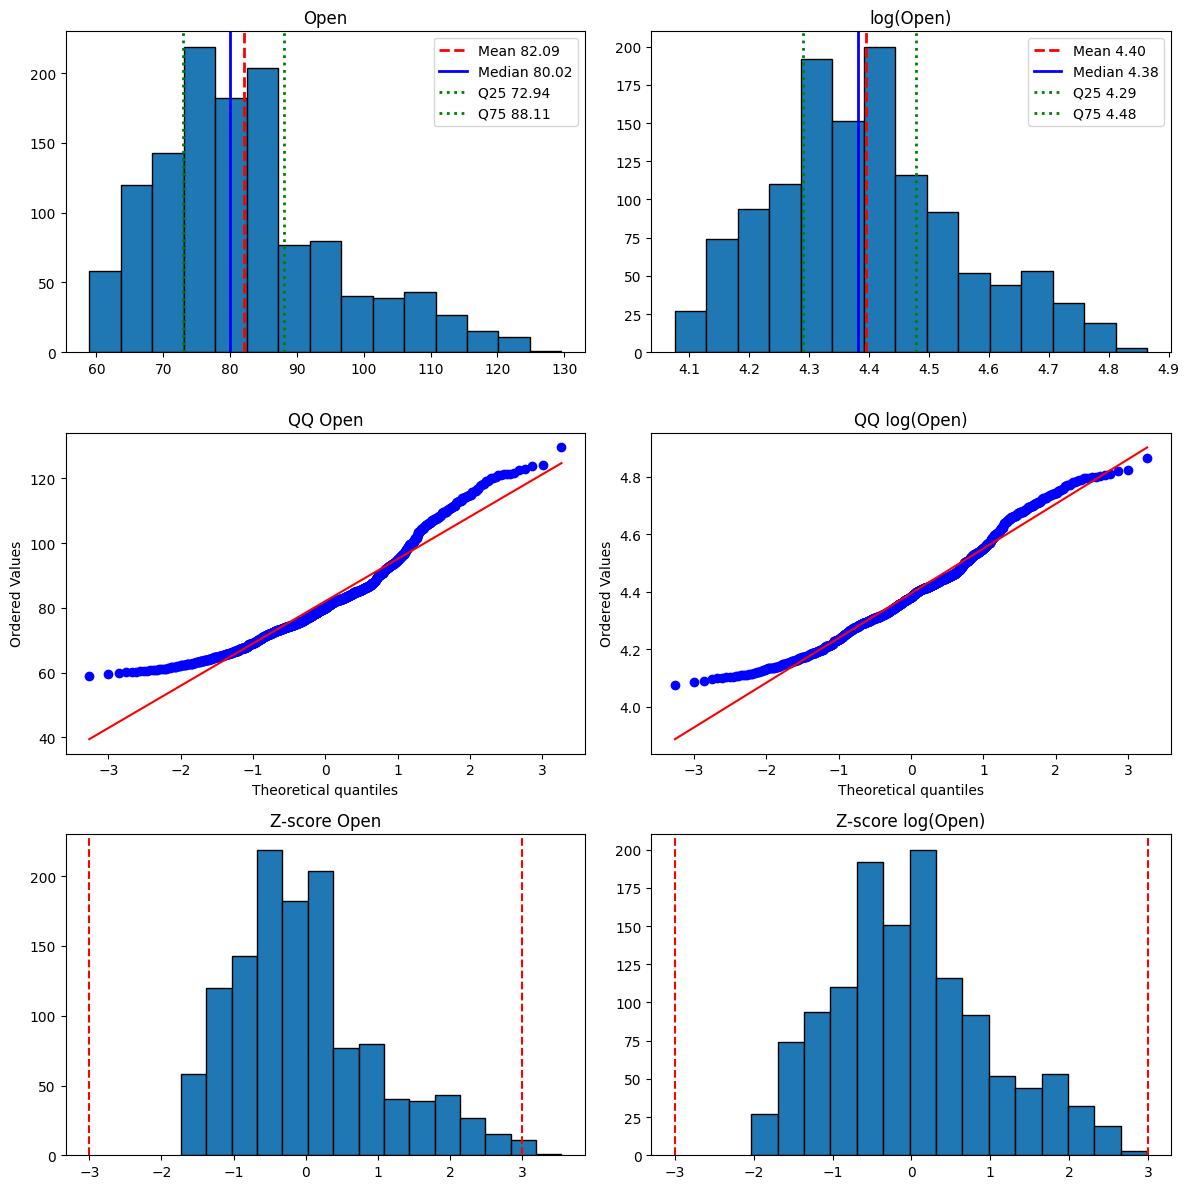

In [248]:
analyze_distribution(df, 'Open')

- На гистограммах четко виден правый хвост. Я могу предположить, что это происходит из-за того, что цена на нефть имеет восходящий тренд.
- В целом распределение визуально близко к нормальному

In [249]:
from collections import defaultdict
from typing import Dict

def get_decomposition_result(
    df: pd.DataFrame
) -> Dict[str, Dict[str, pd.Series]]:
    
    result = defaultdict(dict)

    for column in df.columns:
        df_prophet = df[column].reset_index()
        df_prophet.columns = ["ds", "y"]
        df_prophet["ds"] = df_prophet["ds"].dt.tz_localize(None)

        model = Prophet()
        model.fit(df_prophet)

        forecast = model.predict(df_prophet)

        result[column]["trend"] = forecast["trend"]
        result[column]["seasonality"] = forecast["additive_terms"]
        result[column]["residuals"] = df_prophet["y"] - forecast["yhat"]

    return result


In [250]:
decomp = get_decomposition_result(df)

decomp["Open"]["trend"][0:5]

20:16:21 - cmdstanpy - INFO - Chain [1] start processing
20:16:21 - cmdstanpy - INFO - Chain [1] done processing
20:16:22 - cmdstanpy - INFO - Chain [1] start processing
20:16:22 - cmdstanpy - INFO - Chain [1] done processing
20:16:22 - cmdstanpy - INFO - Chain [1] start processing
20:16:23 - cmdstanpy - INFO - Chain [1] done processing
20:16:23 - cmdstanpy - INFO - Chain [1] start processing
20:16:23 - cmdstanpy - INFO - Chain [1] done processing
20:16:24 - cmdstanpy - INFO - Chain [1] start processing
20:16:24 - cmdstanpy - INFO - Chain [1] done processing
20:16:24 - cmdstanpy - INFO - Chain [1] start processing
20:16:24 - cmdstanpy - INFO - Chain [1] done processing
20:16:25 - cmdstanpy - INFO - Chain [1] start processing
20:16:25 - cmdstanpy - INFO - Chain [1] done processing
20:16:25 - cmdstanpy - INFO - Chain [1] start processing
20:16:25 - cmdstanpy - INFO - Chain [1] done processing
20:16:26 - cmdstanpy - INFO - Chain [1] start processing
20:16:26 - cmdstanpy - INFO - Chain [1]

0    66.015140
1    66.140290
2    66.265440
3    66.390590
4    66.515739
Name: trend, dtype: float64

In [251]:
def plot_decomposition(decomp, column):
    trend = decomp[column]["trend"]
    seasonality = decomp[column]["seasonality"]
    residuals = decomp[column]["residuals"]

    _, axes = plt.subplots(
        3, 1,
        figsize=(15, 10),
        sharex=True
    )

    axes[0].plot(trend)
    axes[0].set_title("Trend")
    axes[0].grid(True)

    axes[1].plot(seasonality)
    axes[1].set_title("Seasonality")
    axes[1].grid(True)

    axes[2].plot(residuals)
    axes[2].set_title("Residuals")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

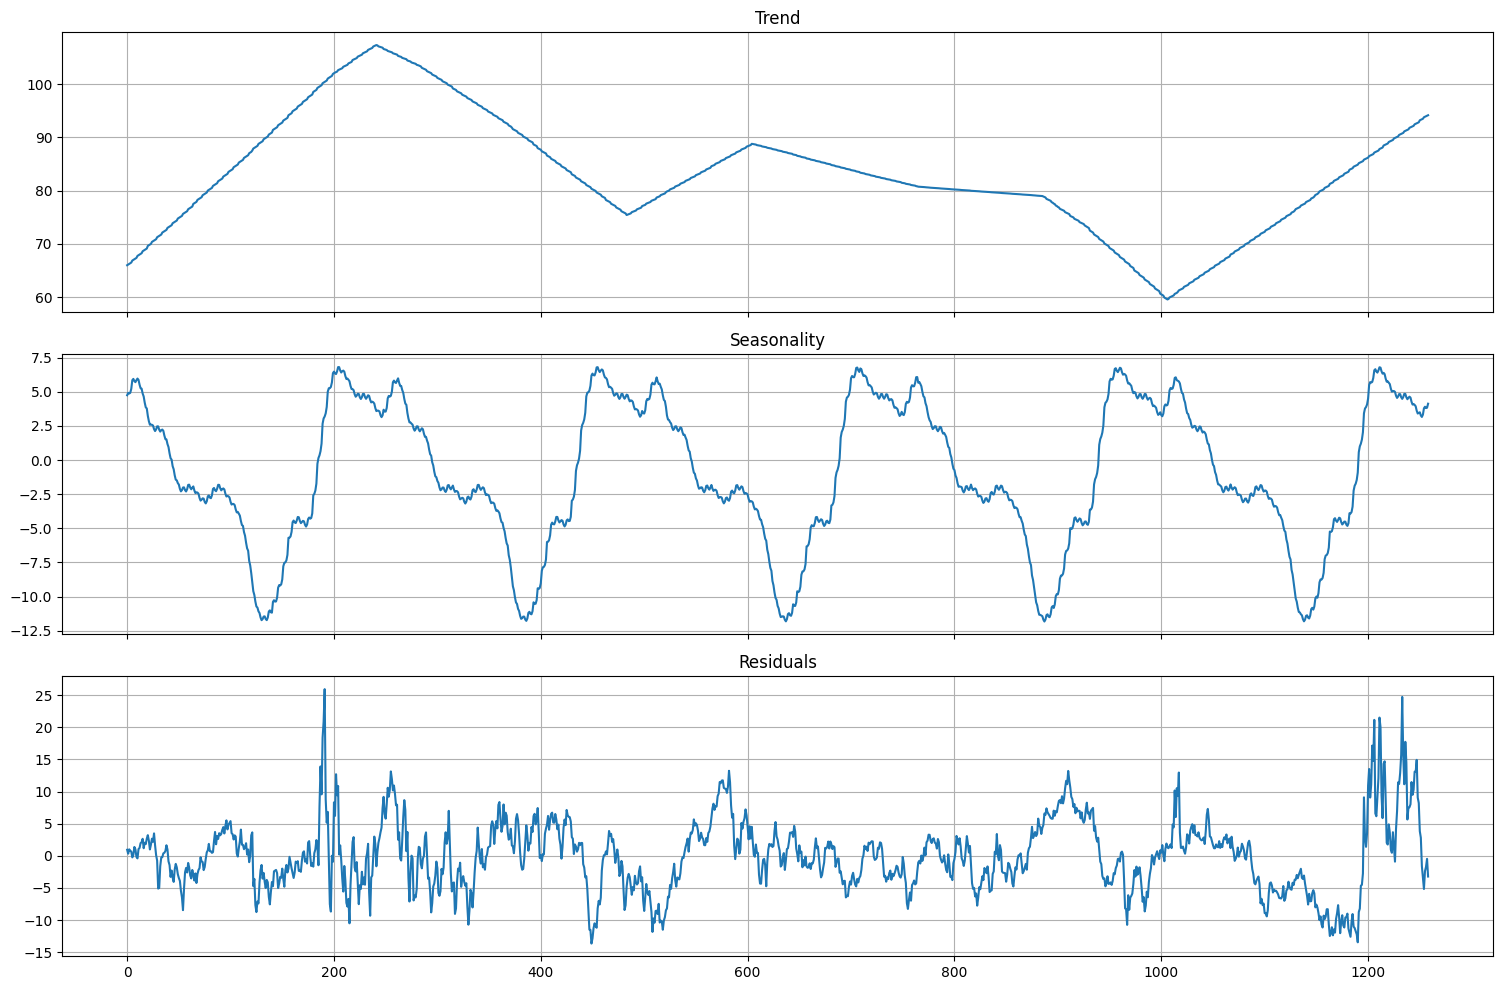

In [252]:
plot_decomposition(decomp, "Open")

- В последнее время много шума на графике в связи с последними событиями
- В последние дни тренд восходящий
- Во времена геополитической нестабильности шума становится больше (например 2022 г февраль на графике соответсвует примерно точке 200)

In [253]:
df_lag = df.diff(periods=1)
df_lag.columns = [f"{col}_lag_1" for col in df.columns]

df = pd.concat([df, df_lag], axis=1)
df = df.dropna()

In [254]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2021-06-08 00:00:00-04:00 to 2026-06-05 00:00:00-04:00
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Open              1258 non-null   float64
 1   High              1258 non-null   float64
 2   Low               1258 non-null   float64
 3   Close             1258 non-null   float64
 4   Volume            1258 non-null   int64  
 5   body              1258 non-null   float64
 6   range             1258 non-null   float64
 7   upper_wick        1258 non-null   float64
 8   lower_wick        1258 non-null   float64
 9   body_pct          1258 non-null   float64
 10  range_pct         1258 non-null   float64
 11  close_pos         1258 non-null   float64
 12  Open_lag_1        1258 non-null   float64
 13  High_lag_1        1258 non-null   float64
 14  Low_lag_1         1258 non-null   float64
 15  Close_lag_1       1258 non-null   float64
 16  Volum

In [255]:
for column in df.columns:
    stat, pvalue, *_ = sm.tsa.adfuller(df[column])
    print(column)
    if pvalue > 0.05: 
        print('Ряд не стационарен')
    else:
        print('Ряд стационарен')
    print('-' * 30)

Open
Ряд не стационарен
------------------------------
High
Ряд не стационарен
------------------------------
Low
Ряд не стационарен
------------------------------
Close
Ряд не стационарен
------------------------------
Volume
Ряд стационарен
------------------------------
body
Ряд стационарен
------------------------------
range
Ряд стационарен
------------------------------
upper_wick
Ряд стационарен
------------------------------
lower_wick
Ряд стационарен
------------------------------
body_pct
Ряд стационарен
------------------------------
range_pct
Ряд стационарен
------------------------------
close_pos
Ряд стационарен
------------------------------
Open_lag_1
Ряд стационарен
------------------------------
High_lag_1
Ряд стационарен
------------------------------
Low_lag_1
Ряд стационарен
------------------------------
Close_lag_1
Ряд стационарен
------------------------------
Volume_lag_1
Ряд стационарен
------------------------------
body_lag_1
Ряд стационарен
----------------

Интегральный ряд первого порядка стационарен.

Проанализируем разницы, так как они стационарны и удобнее для анализа

In [256]:
decomp = get_decomposition_result(df)

20:16:29 - cmdstanpy - INFO - Chain [1] start processing
20:16:29 - cmdstanpy - INFO - Chain [1] done processing
20:16:29 - cmdstanpy - INFO - Chain [1] start processing
20:16:29 - cmdstanpy - INFO - Chain [1] done processing
20:16:30 - cmdstanpy - INFO - Chain [1] start processing
20:16:30 - cmdstanpy - INFO - Chain [1] done processing
20:16:31 - cmdstanpy - INFO - Chain [1] start processing
20:16:31 - cmdstanpy - INFO - Chain [1] done processing
20:16:31 - cmdstanpy - INFO - Chain [1] start processing
20:16:31 - cmdstanpy - INFO - Chain [1] done processing
20:16:32 - cmdstanpy - INFO - Chain [1] start processing
20:16:32 - cmdstanpy - INFO - Chain [1] done processing
20:16:32 - cmdstanpy - INFO - Chain [1] start processing
20:16:32 - cmdstanpy - INFO - Chain [1] done processing
20:16:33 - cmdstanpy - INFO - Chain [1] start processing
20:16:33 - cmdstanpy - INFO - Chain [1] done processing
20:16:33 - cmdstanpy - INFO - Chain [1] start processing
20:16:33 - cmdstanpy - INFO - Chain [1]

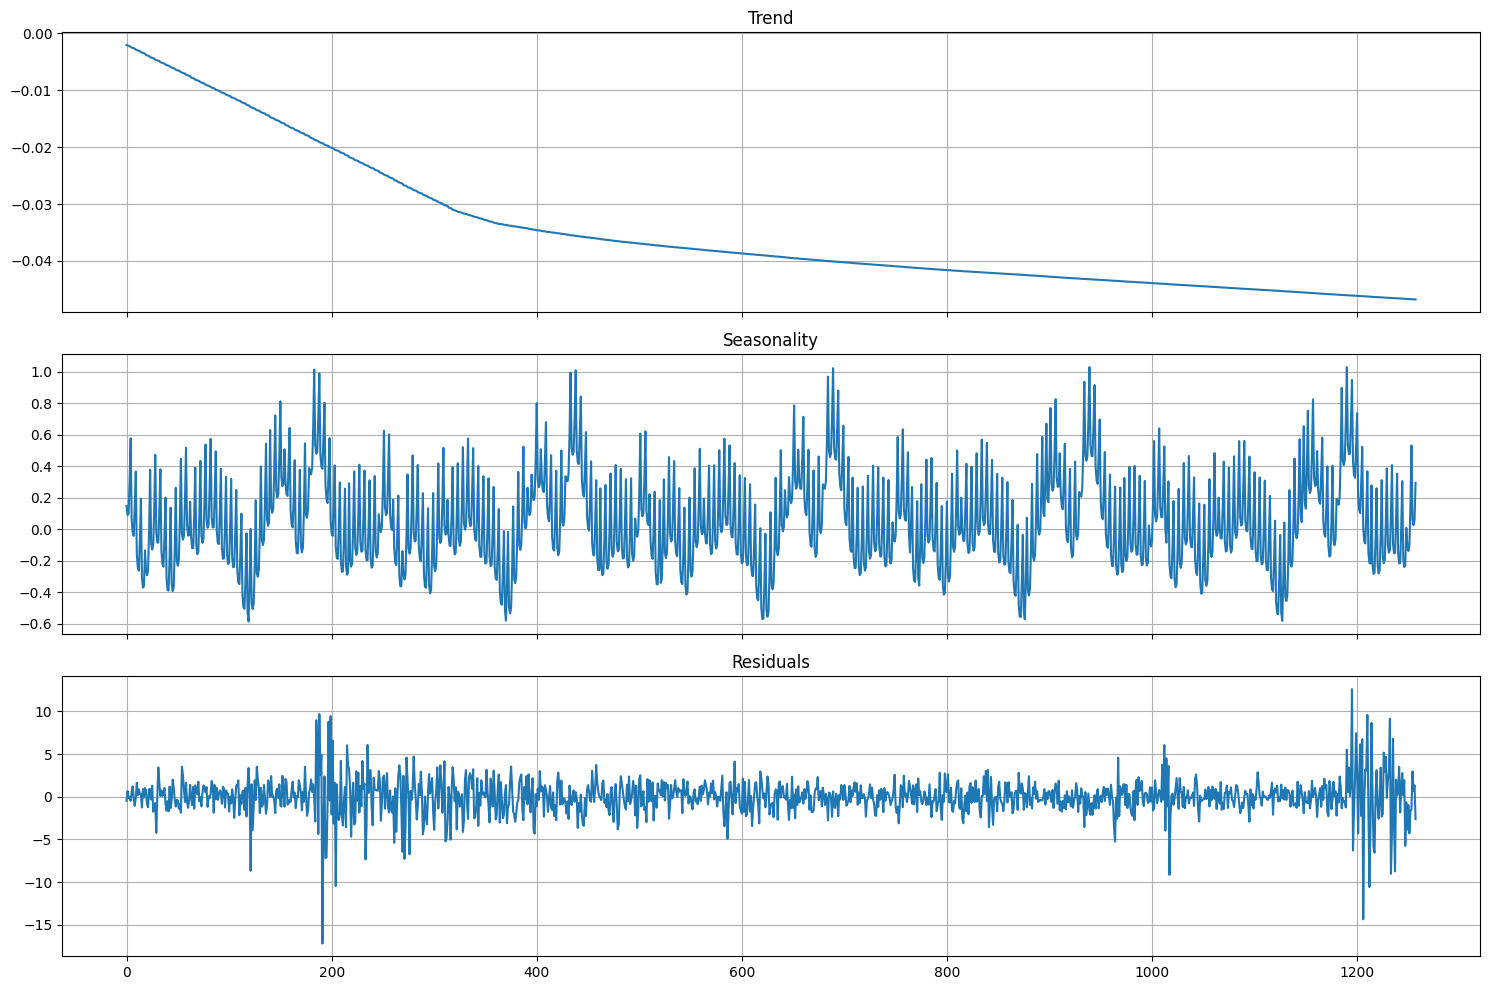

In [257]:
plot_decomposition(decomp, "Open_lag_1")

В целом характеристики графиков не изменились. Так же четко видно 2 всплеска шума. Тренд стал более сглаженным. Сезонность стала более зашумленной

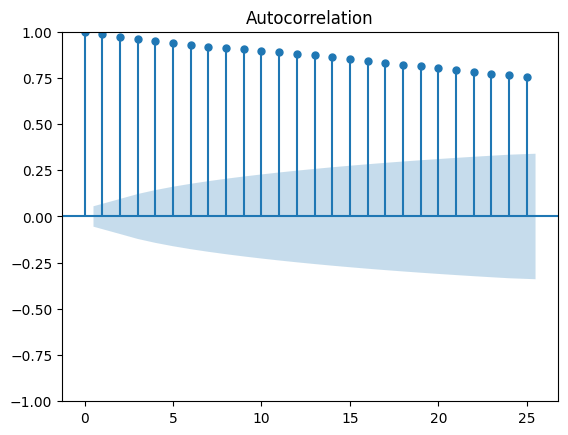

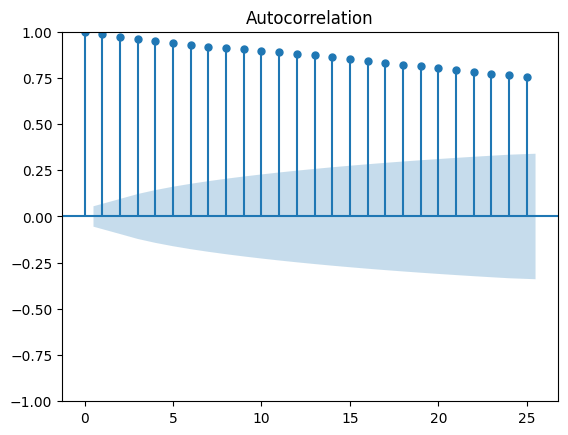

In [258]:
plot_acf(df["Open"], lags=25)

Плавное снижение acf может говорить о трендовости

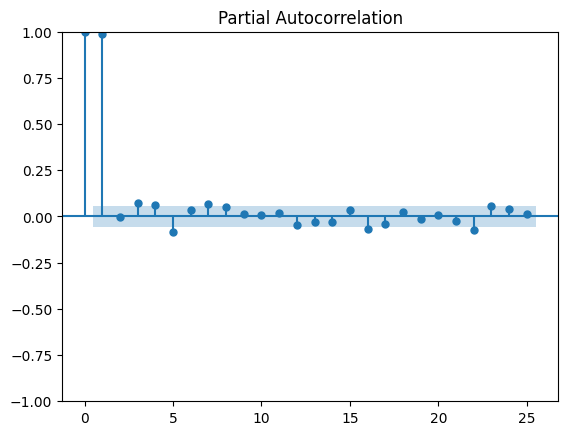

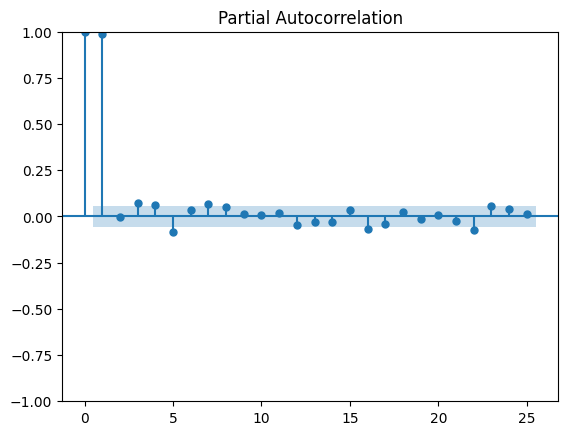

In [259]:
plot_pacf(df["Open"], lags=25)

То есть наиболее сильно влияет комбинация вчера. остальное не так важно для Open

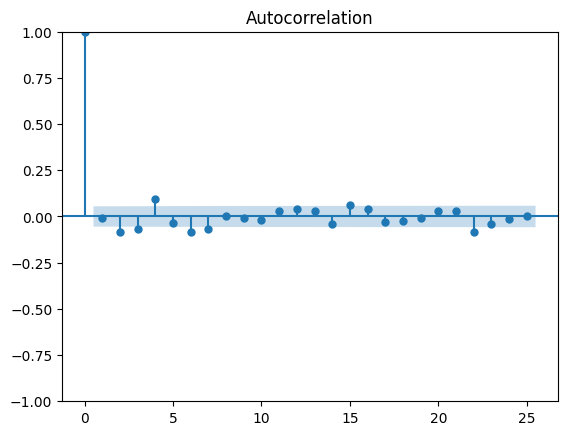

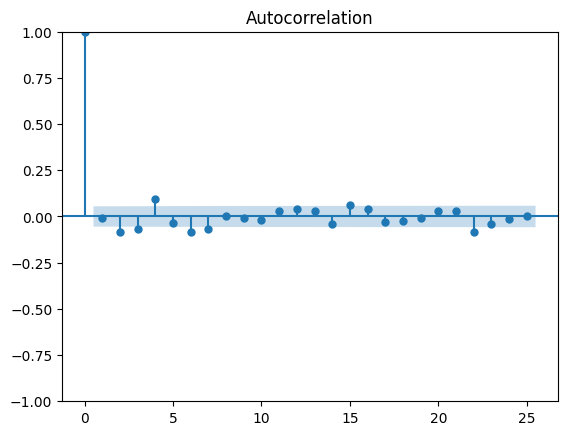

In [260]:
plot_acf(df["Open_lag_1"], lags=25)

А тут вообще никакой корреляции

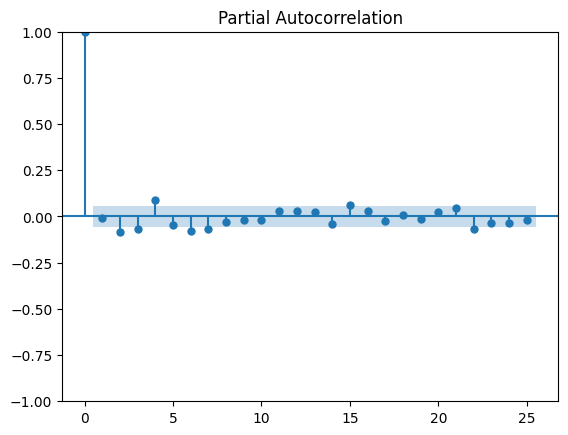

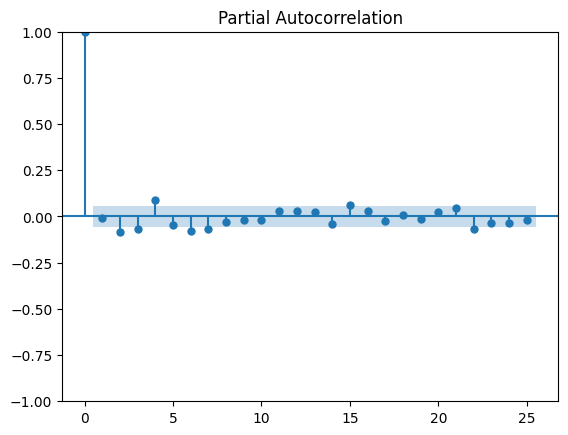

In [261]:
plot_pacf(df["Open_lag_1"], lags=25)

как и тут

In [262]:
stat, p_value = stats.shapiro(decomp["Open"]["residuals"])

if p_value > 0.05:
    print(f"Остатки распределены нормально (p-value={p_value:.4f})")
else:
    print(f"Остатки НЕ распределены нормально (p-value={p_value:.4f})")

Остатки НЕ распределены нормально (p-value=0.0000)


In [263]:
stat, p_value = stats.shapiro(decomp["Open_lag_1"]["residuals"])

if p_value > 0.05:
    print(f"Остатки распределены нормально (p-value={p_value:.4f})")
else:
    print(f"Остатки НЕ распределены нормально (p-value={p_value:.4f})")

Остатки НЕ распределены нормально (p-value=0.0000)


In [264]:
test = sm.stats.diagnostic.acorr_ljungbox(decomp["Open"]["residuals"], lags=[50])
stat = test["lb_stat"].iloc[0]
p_value = test["lb_pvalue"].iloc[0]

if p_value > 0.05:
    print("Автокорреляция не обнаружена")
else:
    print("Есть автокорреляция")
print(f'p_value={p_value:.4f}')

Есть автокорреляция
p_value=0.0000


In [265]:
test = sm.stats.diagnostic.acorr_ljungbox(decomp["Open_lag_1"]["residuals"], lags=[50])
stat = test["lb_stat"].iloc[0]
p_value = test["lb_pvalue"].iloc[0]

if p_value > 0.05:
    print("Автокорреляция не обнаружена")
else:
    print("Есть автокорреляция")
print(f'p_value={p_value:.4f}')

Есть автокорреляция
p_value=0.0000


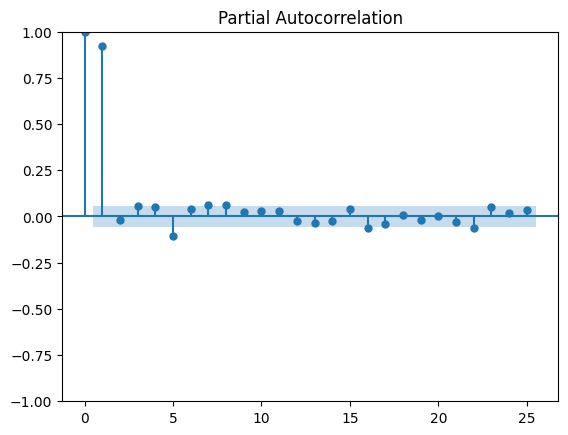

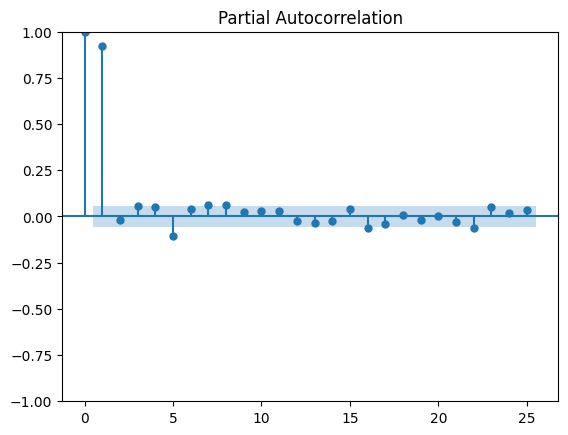

In [266]:
plot_pacf(decomp["Open"]["residuals"], lags=25)

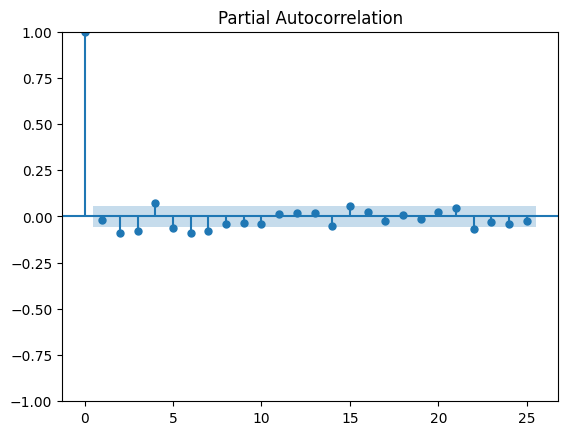

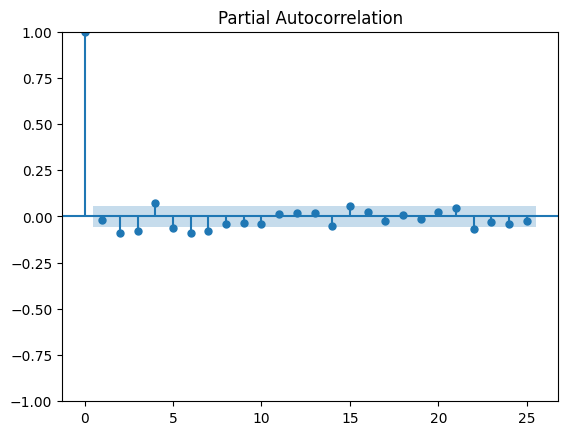

In [267]:
plot_pacf(decomp["Open_lag_1"]["residuals"], lags=25, alpha=0.05)

Тесты показывают, что остатки автокоррелируют. То есть это не просто шум и шум содержит довольно много информации

In [268]:
features = []

for col in columns:

    features.extend(
        [
            df[col].shift(lag).rename(f"{col}_lag_{lag}")
            for lag in range(1, 31)
        ]
    )

    features.extend([
            df[col].shift(season).rename(f"{col}_lag_{season}")
            for season in range(365, df.shape[0], 365)
        ]
    )

    log_col = np.log(df[col].clip(lower=1e-9))

    features.extend(
        [
            log_col.shift(lag).rename(f"{col}_log_lag_{lag}")
            for lag in range(1, 11)
        ]
    )

    features.append(
        df[col].diff().diff().rename(f"{col}_diff2")
    )

In [269]:
windows = [3, 5, 7, 14, 21, 30]

for col in columns:
    for w in windows:
        features.append(
            df[col].rolling(window=w, min_periods=1).mean().rename(f"{col}_ma_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).median().rename(f"{col}_median_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).std().rename(f"{col}_std_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).min().rename(f"{col}_min_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).max().rename(f"{col}_max_{w}")
        )
        
        features.append(
            (df[col].rolling(window=w, min_periods=1).max() - 
             df[col].rolling(window=w, min_periods=1).min()).rename(f"{col}_range_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).var().rename(f"{col}_var_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).skew().rename(f"{col}_skew_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).kurt().rename(f"{col}_kurt_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).quantile(0.25).rename(f"{col}_q25_{w}")
        )
        
        features.append(
            df[col].rolling(window=w, min_periods=1).quantile(0.75).rename(f"{col}_q75_{w}")
        )
        
        q75 = df[col].rolling(window=w, min_periods=1).quantile(0.75)
        q25 = df[col].rolling(window=w, min_periods=1).quantile(0.25)
        features.append(
            (q75 - q25).rename(f"{col}_iqr_{w}")
        )

In [270]:
lengths = [10, 20, 30, 40, 50]

for col in columns:
    for length in lengths:

        features.append(
            ta.ema(df[col], length=length).rename(f"{col}_ema_{length}")
        )

        features.append(
            ta.dema(df[col], length=length).rename(f"{col}_dema_{length}")
        )

        features.append(
            ta.tema(df[col], length=length).rename(f"{col}_tema_{length}")
        )

        features.append(
            ta.kama(df[col], length=length).rename(f"{col}_kama_{length}")
        )

In [271]:
for col in columns:

    # RSI
    for length in [14, 21, 30]:
        features.append(
            ta.rsi(df[col], length=length).rename(f"{col}_rsi_{length}")
        )

    # Stochastic
    stoch = ta.stoch(
        high=df["High"],
        low=df["Low"],
        close=df[col]
    )

    features.append(
        stoch.iloc[:, 0].rename(f"{col}_stoch_k")
    )

    features.append(
        stoch.iloc[:, 1].rename(f"{col}_stoch_d")
    )

    # Williams %R
    for length in [14, 21, 30]:
        features.append(
            ta.willr(
                high=df["High"],
                low=df["Low"],
                close=df[col],
                length=length
            ).rename(f"{col}_willr_{length}")
        )

    # ROC + Momentum
    for length in [5, 10, 20]:
        features.append(
            ta.roc(df[col], length=length).rename(f"{col}_roc_{length}")
        )

        features.append(
            ta.mom(df[col], length=length).rename(f"{col}_mom_{length}")
        )

    # MACD
    macd = ta.macd(df[col])

    features.append(
        macd.iloc[:, 0].rename(f"{col}_macd")
    )

    features.append(
        macd.iloc[:, 1].rename(f"{col}_macd_signal")
    )

    features.append(
        macd.iloc[:, 2].rename(f"{col}_macd_hist")
    )

    # Parabolic SAR
    psar = ta.psar(
        high=df["High"],
        low=df["Low"]
    )

    for c in psar.columns:
        features.append(
            psar[c].rename(f"{col}_{c.lower()}")
        )

    # ADX
    adx = ta.adx(
        high=df["High"],
        low=df["Low"],
        close=df[col]
    )

    features.append(
        adx["ADX_14"].rename(f"{col}_adx")
    )

    features.append(
        adx["DMP_14"].rename(f"{col}_plus_di")
    )

    features.append(
        adx["DMN_14"].rename(f"{col}_minus_di")
    )

    # Bollinger Bands
    bb = ta.bbands(
        df[col],
        length=20
    )

    for c in bb.columns:
        features.append(
            bb[c].rename(f"{col}_{c.lower()}")
        )

    # ATR
    features.append(
        ta.atr(
            high=df["High"],
            low=df["Low"],
            close=df[col],
            length=14
        ).rename(f"{col}_atr")
    )

    # Volatility Ratio
    for length in [10, 20]:
        rolling_std = df[col].rolling(length).std()
        long_std = df[col].rolling(length * 2).std()

        features.append(
            (rolling_std / long_std).rename(
                f"{col}_volatility_ratio_{length}"
            )
        )
    # VWAP
    features.append(
        ta.vwap(
            high=df["High"],
            low=df["Low"],
            close=df["Close"],
            volume=df["Volume"]
        ).rename("vwap")
    )

    # OBV
    features.append(
        ta.obv(
            close=df["Close"],
            volume=df["Volume"]
        ).rename("obv")
    )

    # Accumulation / Distribution
    features.append(
        ta.ad(
            high=df["High"],
            low=df["Low"],
            close=df["Close"],
            volume=df["Volume"]
        ).rename("ad")
    )

In [272]:
idx = pd.DatetimeIndex(df.index)

features.append(
    pd.Series(
        np.sin(2 * np.pi * idx.dayofweek / 7),
        index=idx,
        name="dow_sin"
    )
)

features.append(
    pd.Series(
        np.cos(2 * np.pi * idx.dayofweek / 7),
        index=idx,
        name="dow_cos"
    )
)

features.append(
    pd.Series(
        np.sin(2 * np.pi * (idx.month - 1) / 12),
        index=idx,
        name="month_sin"
    )
)

features.append(
    pd.Series(
        np.cos(2 * np.pi * (idx.month - 1) / 12),
        index=idx,
        name="month_cos"
    )
)

features.append(
    pd.Series(
        np.sin(2 * np.pi * (idx.dayofyear - 1) / 365.25),
        index=idx,
        name="doy_sin"
    )
)

features.append(
    pd.Series(
        np.cos(2 * np.pi * (idx.dayofyear - 1) / 365.25),
        index=idx,
        name="doy_cos"
    )
)



In [273]:
features.append(
    pd.Series(
        idx.is_month_start.astype(bool),
        index=idx,
        name="month_start"
    )
)

features.append(
    pd.Series(
        idx.is_month_end.astype(bool),
        index=idx,
        name="month_end"
    )
)

features.append(
    pd.Series(
        idx.is_quarter_start.astype(bool),
        index=idx,
        name="quarter_start"
    )
)

features.append(
    pd.Series(
        idx.is_quarter_end.astype(bool),
        index=idx,
        name="quarter_end"
    )
)

In [274]:
us_holidays = holidays.US()

features.append(
    pd.Series(
        idx.normalize().isin(us_holidays).astype(bool),
        index=idx,
        name="is_us_holiday"
    )
)

holiday_mask = idx.normalize().isin(us_holidays)

features.append(
    pd.Series(
        np.roll(holiday_mask, 1).astype(bool),
        index=idx,
        name="day_after_holiday"
    )
)

features.append(
    pd.Series(
        np.roll(holiday_mask, -1).astype(bool),
        index=idx,
        name="day_before_holiday"
    )
)

In [275]:
def extract_ts_features(series, idx):
    x = np.asarray(series.dropna(), dtype=np.float64)
    if len(x) < 30:
        return []

    x_centered = x - np.mean(x)
    x_norm = (x - np.mean(x)) / (np.std(x) + 1e-10)
    name = series.name

    def _const(val):
        return pd.Series(val, index=idx, name=name)

    feats = []

    lags = [1, 2, 3, 7, 14, 30]
    lags = [lag for lag in lags if lag < len(x) // 2]


    acf_vals = acf(x, nlags=max(lags))
    for lag in lags:
        feats.append(_const(acf_vals[lag]).rename(f"{name}_acf_lag_{lag}"))

    pacf_vals = pacf(x, nlags=max(lags))
    for lag in lags:
        feats.append(_const(pacf_vals[lag]).rename(f"{name}_pacf_lag_{lag}"))

    feats.append(_const(ant.app_entropy(x_norm)).rename(f"{name}_app_entropy"))

    feats.append(_const(ant.sample_entropy(x_norm)).rename(f"{name}_sample_entropy"))

    feats.append(_const(ant.perm_entropy(x_norm, order=3, delay=1, normalize=True)).rename(f"{name}_perm_entropy"))

    feats.append(_const(ant.spectral_entropy(x_norm, sf=1, method="welch", normalize=True)).rename(f"{name}_spectral_entropy"))


    H, c, _ = compute_Hc(x, kind="change", simplified=True)
    feats.append(_const(H).rename(f"{name}_hurst_h"))
    feats.append(_const(c).rename(f"{name}_hurst_c"))


    feats.append(_const(ant.higuchi_fd(x_norm)).rename(f"{name}_higuchi_fd"))

    feats.append(_const(ant.petrosian_fd(x_norm)).rename(f"{name}_petrosian_fd"))


    feats.append(_const(ant.detrended_fluctuation(x_norm)).rename(f"{name}_dfa"))

    mobility, complexity = ant.hjorth_params(x_norm)
    feats.append(_const(mobility).rename(f"{name}_hjorth_mobility"))
    feats.append(_const(complexity).rename(f"{name}_hjorth_complexity"))

    binary = (x >= np.median(x)).astype(int)
    feats.append(_const(ant.lziv_complexity(binary, normalize=True)).rename(f"{name}_lziv_complexity"))

    feats.append(_const(np.mean(x)).rename(f"{name}_mean"))
    feats.append(_const(np.std(x)).rename(f"{name}_std"))
    feats.append(_const(np.std(x) / (np.abs(np.mean(x)) + 1e-10)).rename(f"{name}_cv"))
    feats.append(_const(np.sum(x ** 2)).rename(f"{name}_signal_energy"))

    feats.append(_const(ant.num_zerocross(x_centered)).rename(f"{name}_zero_crossings"))

    peaks = argrelextrema(x, np.greater, order=5)[0]
    valleys = argrelextrema(x, np.less, order=5)[0]
    feats.append(_const(len(peaks)).rename(f"{name}_n_peaks"))
    feats.append(_const(len(valleys)).rename(f"{name}_n_valleys"))
    feats.append(_const((len(peaks) + len(valleys)) / len(x)).rename(f"{name}_extrema_ratio"))


    sorted_x = np.sort(np.abs(x) + 1e-10)
    n = len(sorted_x)
    index = np.arange(1, n + 1)
    gini = (2 * np.sum(index * sorted_x)) / (n * np.sum(sorted_x)) - (n + 1) / n
    feats.append(_const(gini).rename(f"{name}_gini"))

    return feats


for col in columns:
    features.extend(extract_ts_features(df[col], df.index))

In [ ]:
window_sizes = [64, 128, 256, 512, 1024]
wavelet_types = ['db4', 'db8', 'sym4']
wavelet_levels = [3, 5, 7]
mfcc_counts = [13, 20, 26]
dct_counts = [10, 20, 30]



# Перебор всех колонок
for col in columns:
    # Создаем копию массива с правильным типом данных
    x_full = df[col].values.copy().astype(np.float64)
    
    # --- Фурье-признаки ---
    for ws in window_sizes:
        if len(x_full) < ws:
            continue
        
        # Берем последние ws значений
        x = x_full[-ws:].copy()
        
        # DFT коэффициенты
        fft_vals = np.abs(fft(x))
        features.append(
            pd.Series([np.mean(fft_vals)], name=f"{col}_dft_mean_{ws}")
        )
        
        # Спектральная плотность мощности
        _, pxx = periodogram(x)
        features.append(
            pd.Series([np.mean(pxx)], name=f"{col}_psd_mean_{ws}")
        )
        
        # Спектральный центроид
        weights = fft_vals + 1e-10
        freqs = np.arange(len(weights))
        centroid = np.sum(freqs * weights) / np.sum(weights)
        features.append(
            pd.Series([centroid], name=f"{col}_spectral_centroid_{ws}")
        )
        
        # Спектральная дисперсия
        features.append(
            pd.Series([np.var(fft_vals)], name=f"{col}_spectral_spread_{ws}")
        )
        
        # Доминирующая частота
        features.append(
            pd.Series([np.argmax(fft_vals)], name=f"{col}_dominant_freq_{ws}")
        )
        
        # Спектральная асимметрия
        features.append(
            pd.Series([scipy.stats.skew(fft_vals)], name=f"{col}_spectral_skewness_{ws}")
        )
        
        # Спектральный эксцесс
        features.append(
            pd.Series([scipy.stats.kurtosis(fft_vals)], name=f"{col}_spectral_kurtosis_{ws}")
        )
        
        # Спектральная энтропия
        p = weights / np.sum(weights)
        entropy = -np.sum(p * np.log2(p + 1e-10))
        features.append(
            pd.Series([entropy], name=f"{col}_spectral_entropy_{ws}")
        )
    
    for wavelet_name in wavelet_types:
        for level in wavelet_levels:
            min_len = 2 ** level
            if len(x_full) < min_len:
                continue
            
            data_for_wavelet = x_full.copy()
            coeffs = pywt.wavedec(data_for_wavelet, wavelet_name, level=level)
            
            # Все признаки в одну строку
            features.append(pd.Series([np.mean(coeffs[0])], 
                            name=f"{col}_wavelet_coeff_mean_{wavelet_name}_l{level}"))
            features.append(pd.Series([sum(np.sum(c**2) for c in coeffs)], 
                            name=f"{col}_wavelet_energy_{wavelet_name}_l{level}"))
            features.append(pd.Series([sum(shannon_entropy(c**2, base=2) for c in coeffs if np.sum(c**2) > 0)], 
                            name=f"{col}_wavelet_entropy_{wavelet_name}_l{level}"))

TypeError: 'numpy.float64' object is not callable

In [277]:
open_price = df['Open'].values
high_price = df['High'].values
low_price = df['Low'].values
close_price = df['Close'].values

patterns_df = df.ta.cdl_pattern(
    name=[
        "doji", "hammer", "engulfing", "shootingstar",
        "hangingman", "morningstar", "eveningstar"
    ],  
    open=open_price,
    high=high_price,
    low=low_price,
    close=close_price,
    talib=False
)

In [278]:
features_df = pd.concat(features, axis=1)
df = pd.concat([df, features_df, patterns_df], axis=1)
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'body', 'range', 'upper_wick',
       'lower_wick', 'body_pct',
       ...
       'Low_lag_1', 'Close_lag_1', 'Volume_lag_1', 'body_lag_1', 'range_lag_1',
       'upper_wick_lag_1', 'lower_wick_lag_1', 'body_pct_lag_1',
       'range_pct_lag_1', 'close_pos_lag_1'],
      dtype='str', length=2551)